# Training Visualization: Approach A vs B

This notebook loads training metrics from both approaches and visualizes:
1. Loss curves (train / validation)
2. Accuracy curves (overall, redshift, spectrum)
3. Side-by-side comparison of Approach A (joint) vs B (masked)

**Data:** 269 DESI spectra, 10 epochs, 256d/2-layer model
**Split:** Random 90/10 shuffle (seed=42) for representative validation

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# Load metrics (honest random split, seed=42)
metrics_a = json.load(open('../checkpoints/approach_a_fixed_split/approach_a/metrics.json'))
metrics_b = json.load(open('../checkpoints/approach_b_fixed_split/approach_b/metrics.json'))

print(f"Approach A: {len(metrics_a)} epochs")
print(f"Approach B: {len(metrics_b)} epochs")

Approach A: 10 epochs
Approach B: 10 epochs


## Parse Metrics into Arrays

In [2]:
def parse_metrics(metrics):
    epochs = []
    train_loss = []
    val_loss = []
    train_acc = []
    val_acc = []
    train_redshift_acc = []
    val_redshift_acc = []
    train_spectrum_acc = []
    val_spectrum_acc = []
    
    for m in metrics:
        epochs.append(m['epoch'])
        train_loss.append(m['train_loss'])
        val_loss.append(m['val_loss'])
        train_acc.append(m['train_overall_acc'])
        val_acc.append(m['val_overall_acc'])
        train_redshift_acc.append(m['train_redshift_acc'])
        val_redshift_acc.append(m['val_redshift_acc'])
        train_spectrum_acc.append(m['train_spectrum_acc'])
        val_spectrum_acc.append(m['val_spectrum_acc'])
    
    return {
        'epochs': np.array(epochs),
        'train_loss': np.array(train_loss),
        'val_loss': np.array(val_loss),
        'train_acc': np.array(train_acc),
        'val_acc': np.array(val_acc),
        'train_redshift_acc': np.array(train_redshift_acc),
        'val_redshift_acc': np.array(val_redshift_acc),
        'train_spectrum_acc': np.array(train_spectrum_acc),
        'val_spectrum_acc': np.array(val_spectrum_acc),
    }

a = parse_metrics(metrics_a)
b = parse_metrics(metrics_b)

print("Metrics parsed successfully")

Metrics parsed successfully


## Loss Curves

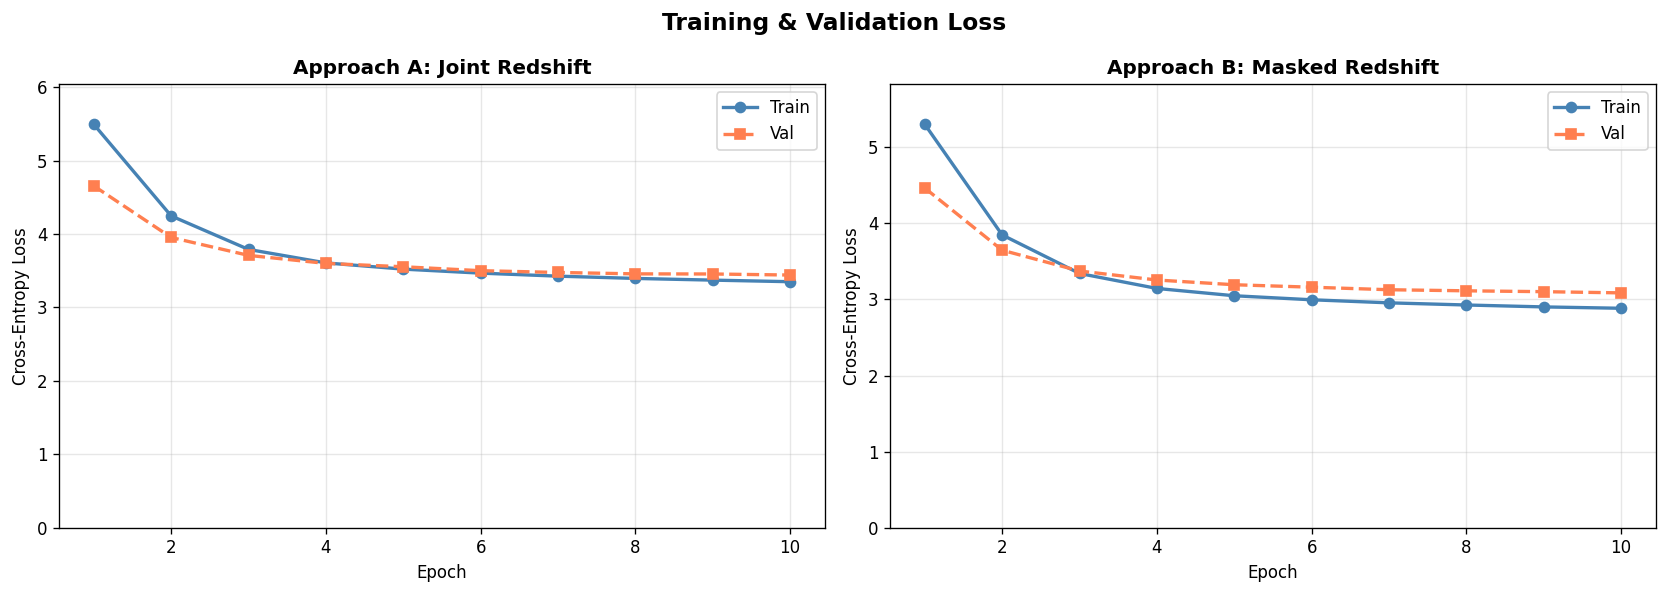


Approach A - Best val loss: 3.4407 @ epoch 10
Approach B - Best val loss: 3.0864 @ epoch 10


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Approach A
axes[0].plot(a['epochs'], a['train_loss'], 'o-', color='steelblue', label='Train', linewidth=2)
axes[0].plot(a['epochs'], a['val_loss'], 's--', color='coral', label='Val', linewidth=2)
axes[0].set_title('Approach A: Joint Redshift', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, max(a['train_loss'].max(), a['val_loss'].max()) * 1.1)

# Approach B
axes[1].plot(b['epochs'], b['train_loss'], 'o-', color='steelblue', label='Train', linewidth=2)
axes[1].plot(b['epochs'], b['val_loss'], 's--', color='coral', label='Val', linewidth=2)
axes[1].set_title('Approach B: Masked Redshift', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, max(b['train_loss'].max(), b['val_loss'].max()) * 1.1)

plt.suptitle('Training & Validation Loss', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nApproach A - Best val loss: {a['val_loss'].min():.4f} @ epoch {a['epochs'][a['val_loss'].argmin()]}")
print(f"Approach B - Best val loss: {b['val_loss'].min():.4f} @ epoch {b['epochs'][b['val_loss'].argmin()]}")

## Overall Accuracy

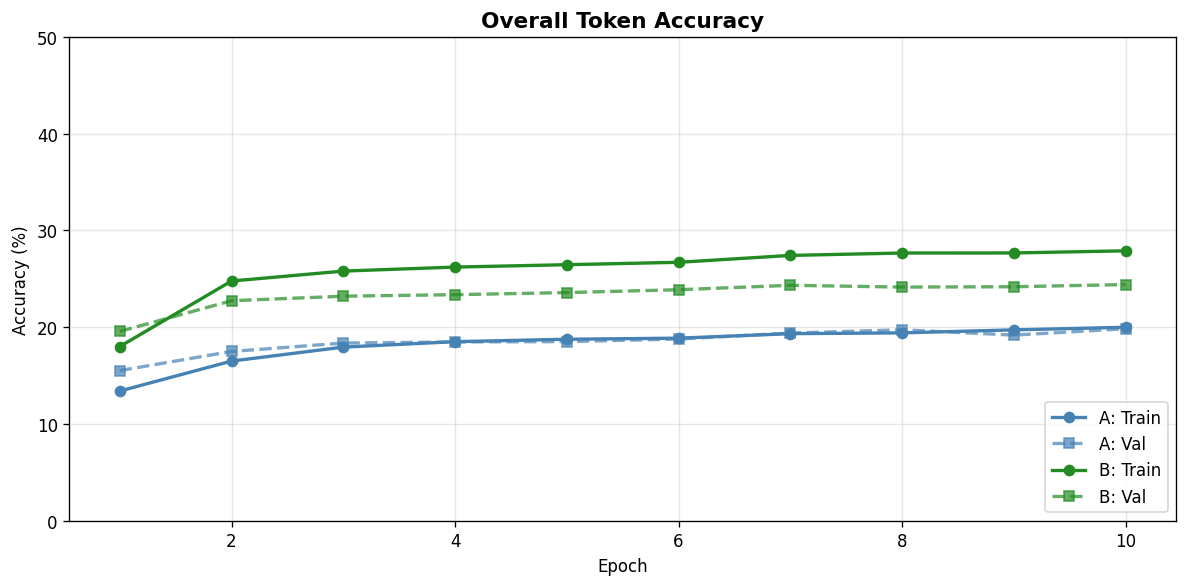

Approach A - Best val acc: 19.8% @ epoch 10
Approach B - Best val acc: 24.4% @ epoch 10


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(a['epochs'], a['train_acc'] * 100, 'o-', color='steelblue', label='A: Train', linewidth=2)
ax.plot(a['epochs'], a['val_acc'] * 100, 's--', color='steelblue', label='A: Val', alpha=0.7, linewidth=2)
ax.plot(b['epochs'], b['train_acc'] * 100, 'o-', color='forestgreen', label='B: Train', linewidth=2)
ax.plot(b['epochs'], b['val_acc'] * 100, 's--', color='forestgreen', label='B: Val', alpha=0.7, linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Overall Token Accuracy', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 50)

plt.tight_layout()
plt.show()

print(f"Approach A - Best val acc: {a['val_acc'].max()*100:.1f}% @ epoch {a['epochs'][a['val_acc'].argmax()]}")
print(f"Approach B - Best val acc: {b['val_acc'].max()*100:.1f}% @ epoch {b['epochs'][b['val_acc'].argmax()]}")

## Redshift Accuracy

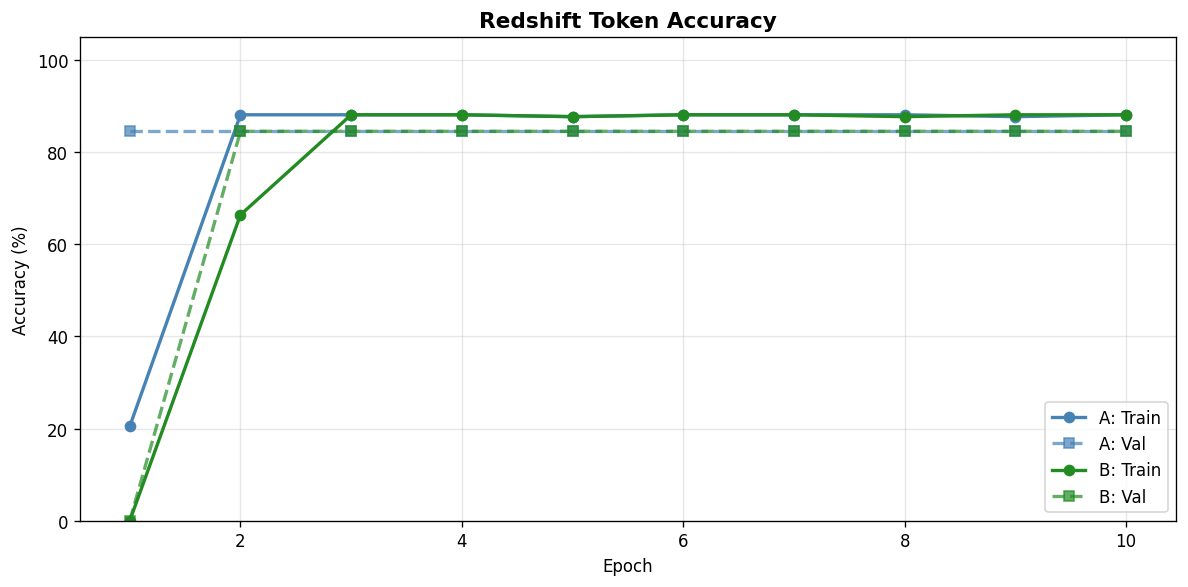

Approach A - Final val redshift acc: 84.5%
Approach B - Final val redshift acc: 84.5%


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(a['epochs'], a['train_redshift_acc'] * 100, 'o-', color='steelblue', label='A: Train', linewidth=2)
ax.plot(a['epochs'], a['val_redshift_acc'] * 100, 's--', color='steelblue', label='A: Val', alpha=0.7, linewidth=2)
ax.plot(b['epochs'], b['train_redshift_acc'] * 100, 'o-', color='forestgreen', label='B: Train', linewidth=2)
ax.plot(b['epochs'], b['val_redshift_acc'] * 100, 's--', color='forestgreen', label='B: Val', alpha=0.7, linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Redshift Token Accuracy', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

print(f"Approach A - Final val redshift acc: {a['val_redshift_acc'][-1]*100:.1f}%")
print(f"Approach B - Final val redshift acc: {b['val_redshift_acc'][-1]*100:.1f}%")

## Spectrum Token Accuracy

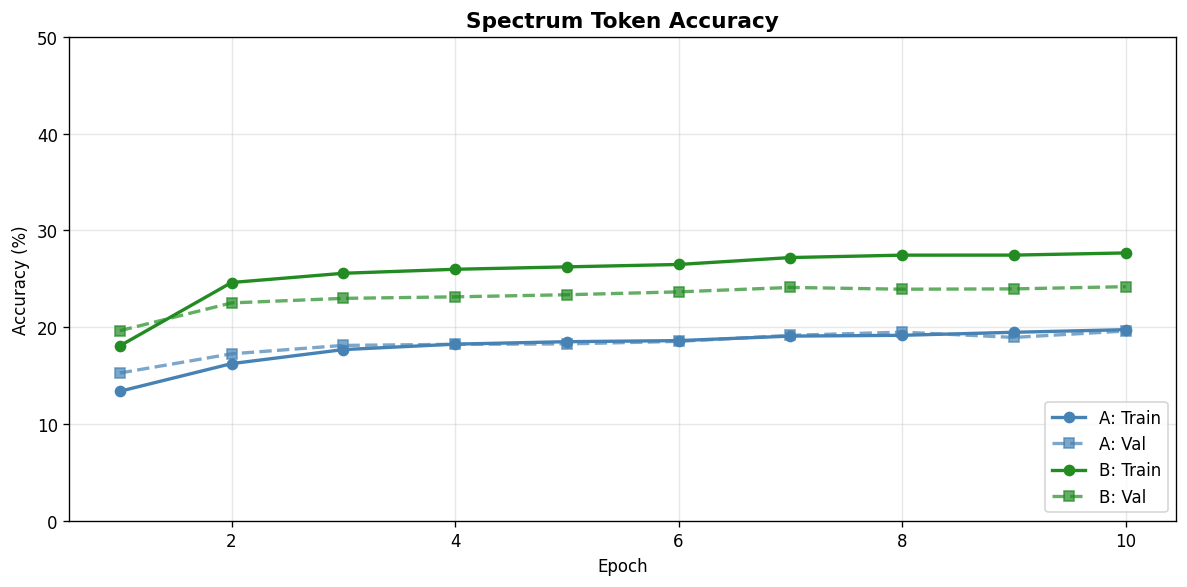

Approach A - Best val spectrum acc: 19.6% @ epoch 10
Approach B - Best val spectrum acc: 24.2% @ epoch 10


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(a['epochs'], a['train_spectrum_acc'] * 100, 'o-', color='steelblue', label='A: Train', linewidth=2)
ax.plot(a['epochs'], a['val_spectrum_acc'] * 100, 's--', color='steelblue', label='A: Val', alpha=0.7, linewidth=2)
ax.plot(b['epochs'], b['train_spectrum_acc'] * 100, 'o-', color='forestgreen', label='B: Train', linewidth=2)
ax.plot(b['epochs'], b['val_spectrum_acc'] * 100, 's--', color='forestgreen', label='B: Val', alpha=0.7, linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Spectrum Token Accuracy', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 50)

plt.tight_layout()
plt.show()

print(f"Approach A - Best val spectrum acc: {a['val_spectrum_acc'].max()*100:.1f}% @ epoch {a['epochs'][a['val_spectrum_acc'].argmax()]}")
print(f"Approach B - Best val spectrum acc: {b['val_spectrum_acc'].max()*100:.1f}% @ epoch {b['epochs'][b['val_spectrum_acc'].argmax()]}")

## Side-by-Side Comparison (Final Epoch)

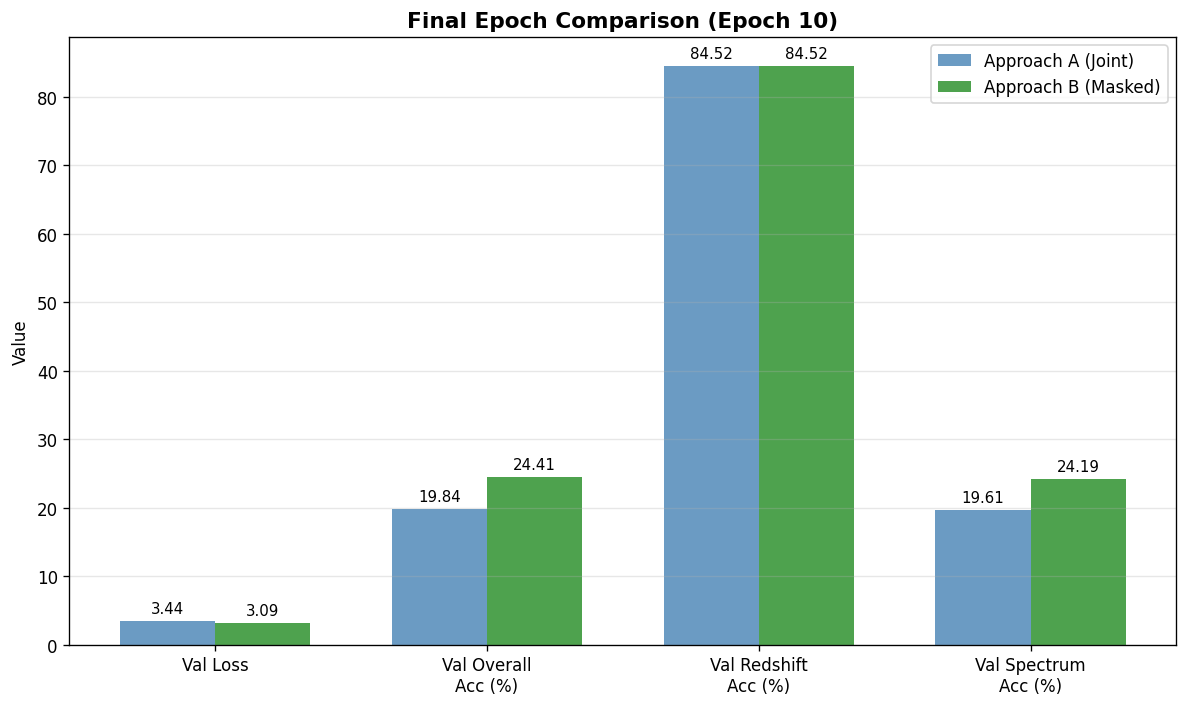

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Val Loss', 'Val Overall\nAcc (%)', 'Val Redshift\nAcc (%)', 'Val Spectrum\nAcc (%)']
a_vals = [
    a['val_loss'][-1],
    a['val_acc'][-1] * 100,
    a['val_redshift_acc'][-1] * 100,
    a['val_spectrum_acc'][-1] * 100,
]
b_vals = [
    b['val_loss'][-1],
    b['val_acc'][-1] * 100,
    b['val_redshift_acc'][-1] * 100,
    b['val_spectrum_acc'][-1] * 100,
]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, a_vals, width, label='Approach A (Joint)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, b_vals, width, label='Approach B (Masked)', color='forestgreen', alpha=0.8)

ax.set_ylabel('Value')
ax.set_title('Final Epoch Comparison (Epoch 10)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Summary

**Key findings (10 epochs, 269 spectra, random split):**

| Metric | Approach A (Joint) | Approach B (Masked) |
|--------|-------------------|---------------------|
| Best Val Loss | 3.44 | 3.09 |
| Final Val Acc | ~20% | ~24% |
| Redshift Acc | 84.5% | 84.5% |
| Spectrum Acc | ~19% | ~23% |

**Observations:**
- Approach B achieves lower validation loss (3.09 vs 3.44) — masked training forces better generalization
- Both approaches achieve ~84.5% redshift accuracy on honest validation (mix of stars + galaxies)
- Model correctly identifies stars but struggles with galaxies (needs more data)
- Overall accuracy is low because the tokenizer is untrained (random init)
- With a trained tokenizer + NERSC-scale data, accuracy should improve dramatically